In [2]:
#Lab 3.1 — CNN Fundamentals: Convolution, Pooling, Padding, Strides
#1 Imports & data
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
tfm = transforms.ToTensor()
train = datasets.FashionMNIST('data', train=True, download=True, transform=tfm)
test = datasets.FashionMNIST('data', train=False, download=True, transform=tfm)
train_dl = DataLoader(train, batch_size=128, shuffle=True)
test_dl = DataLoader(test, batch_size=256)

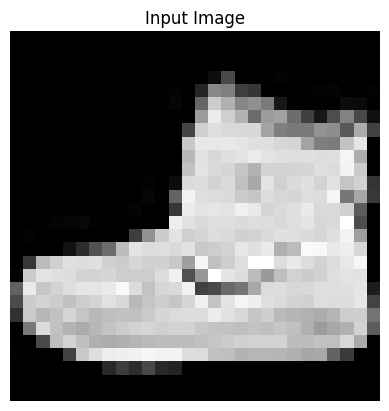

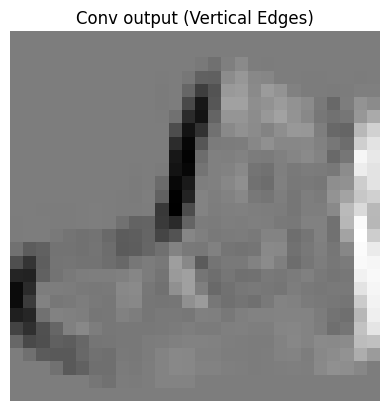

In [3]:
#2 Manual convolution demo
sample, _ = train[0]
plt.imshow(sample.squeeze(), cmap="gray")
plt.title("Input Image")
plt.axis("off") # Fixed
plt.show()

conv = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1, bias=False)

# Fixed the tensor structure and closed brackets
with torch.no_grad():
    edge_kernel = torch.tensor([[[[1, 0, -1], 
                                  [1, 0, -1], 
                                  [1, 0, -1]]]], dtype=torch.float32)
    conv.weight.copy_(edge_kernel)

out = conv(sample.unsqueeze(0))

# Detach and squeeze for plotting
plt.imshow(out.squeeze().detach(), cmap="gray")
plt.title("Conv output (Vertical Edges)")
plt.axis("off")
plt.show()

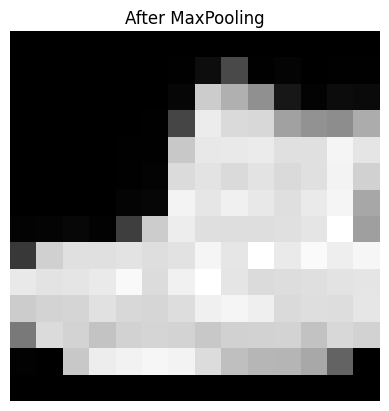

In [4]:
#3 Pooling demo
pool = nn.MaxPool2d(2, 2)
# sample.unsqueeze(0) turns (1, 28, 28) into (1, 1, 28, 28)
pooled = pool(sample.unsqueeze(0))

plt.imshow(pooled.squeeze().detach(), cmap="gray")
plt.title("After MaxPooling")
plt.axis("off") 
plt.show()

In [5]:
#4 Simple CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64*7*7,128), nn.ReLU(), nn.Linear(128,10)
        )
    def forward(self,x): return self.net(x)

# This creates the actual model 'm' or 'model'
m = SimpleCNN() 

# If you have a GPU, move it to the device immediately after defining
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
m = m.to(device)

In [6]:
#5 Training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, epochs=3):
    model = model.to(device) # Move model to device
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(epochs):
        model.train(); tot=0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device) # Move data to device
            opt.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            tot += loss.item() * x.size(0)
        print(f"Epoch {ep+1}, Train loss {tot/len(train_dl.dataset):.4f}")
    return model

# Instantiate the model and run the training function
model_instance = SimpleCNN()
m = train_model(model_instance, epochs=3)

Epoch 1, Train loss 0.5150
Epoch 2, Train loss 0.3270
Epoch 3, Train loss 0.2825


Test accuracy: 0.8877


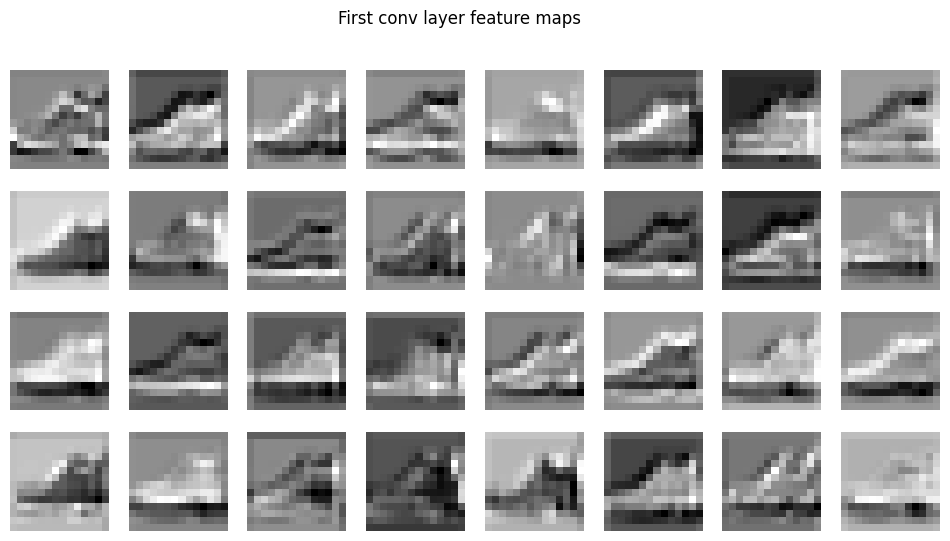

In [8]:
#6 Evaluate & visualize feature maps
def accuracy(model, dl):
    model.eval()
    correct = 0; total = 0
    device = next(model.parameters()).device # Get model's current device
    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            p = model(x).argmax(1)
            correct += (p == y).sum().item()
            total += y.size(0)
    return correct / total

print(f"Test accuracy: {accuracy(m, test_dl):.4f}")

# Visualize intermediate activations
device = next(m.parameters()).device
x, _ = test[0]
x = x.unsqueeze(0).to(device)

# m.net[:4] grabs Conv2d, ReLU, MaxPool, Conv2d
acts = m.net[:4](x) 

fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axs.flat):
    if i < acts.shape[1]: # Ensure we don't exceed channel count
        ax.imshow(acts[0, i].detach().cpu(), cmap="gray")
    ax.axis("off")

plt.suptitle("First conv layer feature maps")
plt.show()